# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [2]:
df = pd.read_csv('lending_club_loan_two.csv')

# Dataset Overview

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

In [5]:
df['loan_status'].value_counts()

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

In [6]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


# Data Cleaning

In [7]:
missing_percent = 100 * df.isnull().sum() / len(df)
print("--- Percentage of Missing Values ---")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

--- Percentage of Missing Values ---
mort_acc                9.543469
emp_title               5.789208
emp_length              4.621115
title                   0.443401
pub_rec_bankruptcies    0.135091
revol_util              0.069692
dtype: float64


In [8]:
df = df.drop('emp_title', axis=1)
df = df.drop('emp_length', axis=1)


In [9]:
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].mean())

In [10]:
df = df.dropna()

In [11]:
print(df.isnull().sum().max())

0


In [12]:
df.shape

(393464, 25)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 393464 entries, 0 to 396029
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             393464 non-null  float64
 1   term                  393464 non-null  str    
 2   int_rate              393464 non-null  float64
 3   installment           393464 non-null  float64
 4   grade                 393464 non-null  str    
 5   sub_grade             393464 non-null  str    
 6   home_ownership        393464 non-null  str    
 7   annual_inc            393464 non-null  float64
 8   verification_status   393464 non-null  str    
 9   issue_d               393464 non-null  str    
 10  loan_status           393464 non-null  str    
 11  purpose               393464 non-null  str    
 12  title                 393464 non-null  str    
 13  dti                   393464 non-null  float64
 14  earliest_cr_line      393464 non-null  str    
 15  open_acc        

In [14]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,RENT,117000.0,Not Verified,Jan-2015,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,MORTGAGE,65000.0,Not Verified,Jan-2015,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,RENT,43057.0,Source Verified,Jan-2015,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,RENT,54000.0,Not Verified,Nov-2014,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,MORTGAGE,55000.0,Verified,Apr-2013,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [15]:
df.isnull().values.any()

np.False_

# Encode Categorical Values

In [16]:
df.select_dtypes(include='object').columns

/tmp/ipykernel_49607/3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'title', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='str')

In [17]:
df['default_risk'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
df = df.drop('loan_status', axis=1)

In [18]:
df['term'] = df['term'].apply(lambda x: int(x[:3]))

In [19]:
df = df.drop('grade', axis=1)

In [20]:
df = df.drop('title', axis=1)

In [21]:
categorical_cols = ['sub_grade', 'verification_status', 'purpose', 
                    'initial_list_status', 'application_type', 'home_ownership']

dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

df = df.drop(categorical_cols, axis=1)
df = pd.concat([df, dummies], axis=1)

In [22]:
df.select_dtypes(['object']).columns

/tmp/ipykernel_49607/1857401351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(['object']).columns


Index(['issue_d', 'earliest_cr_line', 'address'], dtype='str')

In [23]:
df.shape

(393464, 74)

In [ ]:
print(list(df.columns))


['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'issue_d', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'address', 'default_risk', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_me

In [25]:
df['zip_code'] = df['address'].apply(lambda address: address[-5:])

In [26]:
zip_dummies = pd.get_dummies(df['zip_code'], drop_first=True)
df = df.drop(['address', 'zip_code'], axis=1)
df = pd.concat([df, zip_dummies], axis=1)

In [27]:
df = df.drop('issue_d', axis=1)

In [28]:
df['earliest_cr_year'] = df['earliest_cr_line'].apply(lambda date: int(date[-4:]))
df = df.drop('earliest_cr_line', axis=1)

In [29]:
df.shape

(393464, 81)

In [30]:
len(df.select_dtypes(['object']).columns)

0

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 393464 entries, 0 to 396029
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            393464 non-null  float64
 1   term                                 393464 non-null  int64  
 2   int_rate                             393464 non-null  float64
 3   installment                          393464 non-null  float64
 4   annual_inc                           393464 non-null  float64
 5   dti                                  393464 non-null  float64
 6   open_acc                             393464 non-null  float64
 7   pub_rec                              393464 non-null  float64
 8   revol_bal                            393464 non-null  float64
 9   revol_util                           393464 non-null  float64
 10  total_acc                            393464 non-null  float64
 11  mort_acc                     

# Exploratory Data Analysis

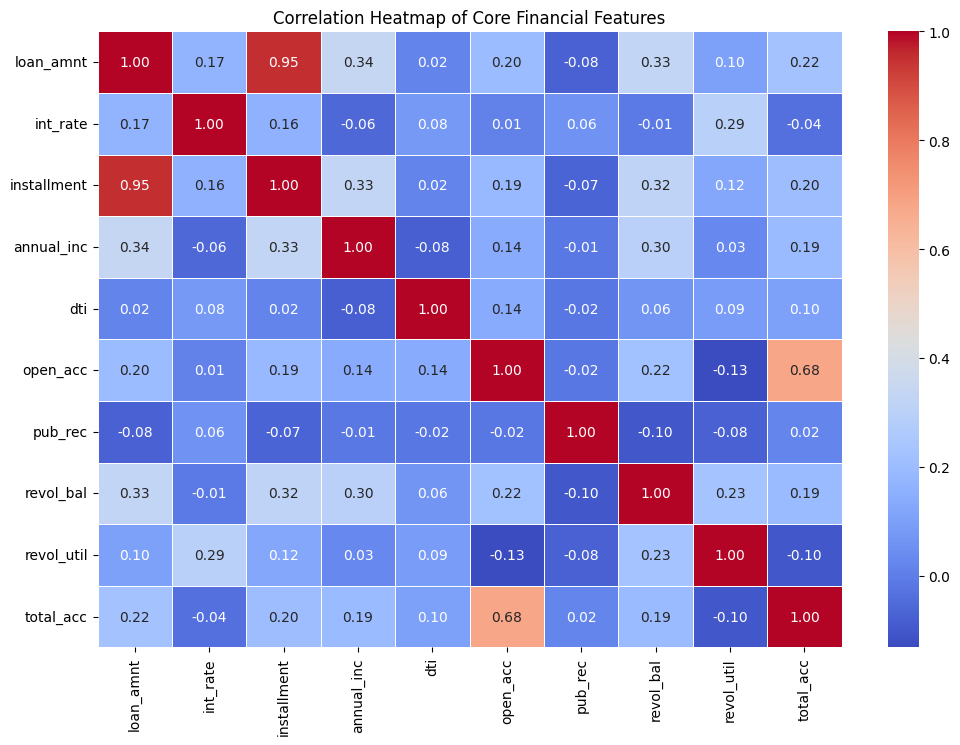

In [32]:
core_numeric = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

plt.figure(figsize=(12, 8))
sns.heatmap(df[core_numeric].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Core Financial Features')
plt.show()

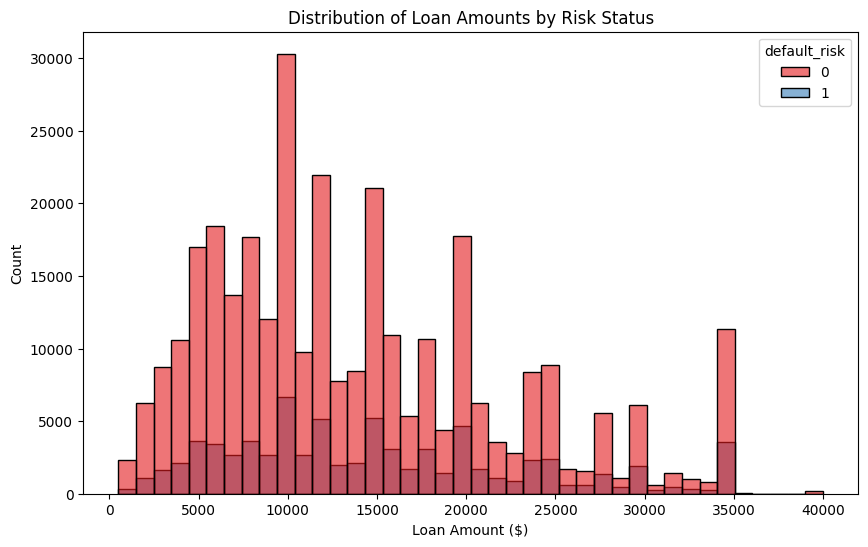

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='loan_amnt', hue='default_risk', bins=40, kde=False, palette='Set1', alpha=0.6)
plt.title('Distribution of Loan Amounts by Risk Status')
plt.xlabel('Loan Amount ($)')
plt.show()

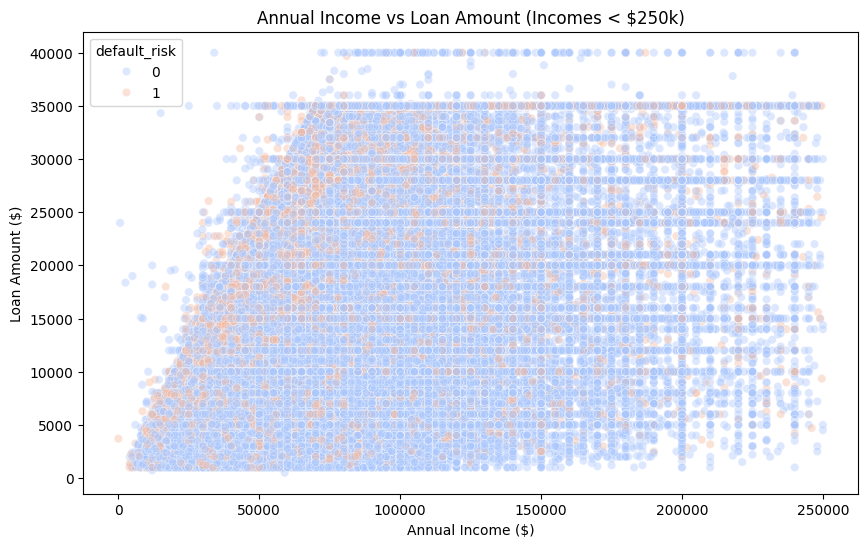

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['annual_inc'] < 250000], x='annual_inc', y='loan_amnt', hue='default_risk', alpha=0.4, palette='coolwarm')
plt.title('Annual Income vs Loan Amount (Incomes < $250k)')
plt.xlabel('Annual Income ($)')
plt.ylabel('Loan Amount ($)')
plt.show()

In [35]:
plt.figure(figsize=(10, 6))
correlation_data = df.corr()['default_risk'].sort_values().drop('default_risk')

<Figure size 1000x600 with 0 Axes>

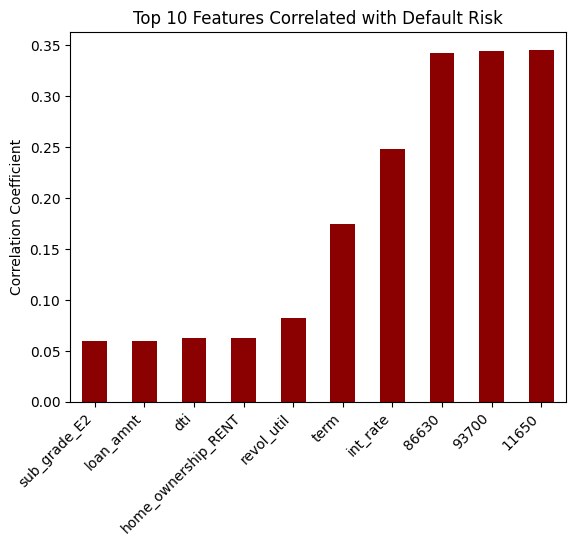

In [36]:
correlation_data.tail(10).plot(kind='bar', color='darkred')
plt.title('Top 10 Features Correlated with Default Risk')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_49607/4078448786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_risk', y='int_rate', data=df, palette='Set2')


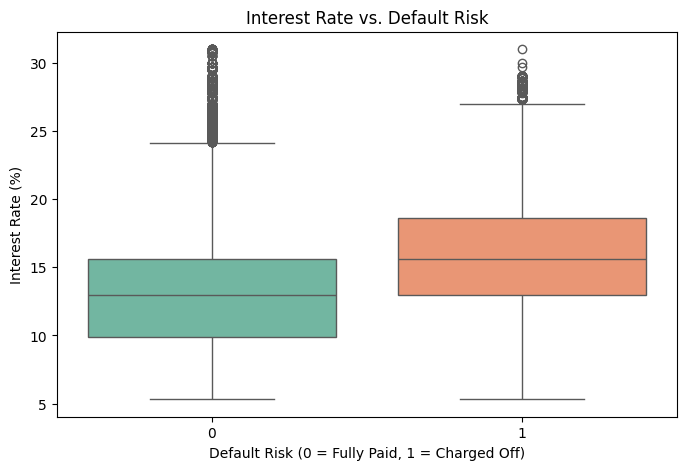

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='default_risk', y='int_rate', data=df, palette='Set2')
plt.title('Interest Rate vs. Default Risk')
plt.xlabel('Default Risk (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Interest Rate (%)')
plt.show()

In [38]:
df.to_csv('Cleaned_Dataset.csv', index=False)

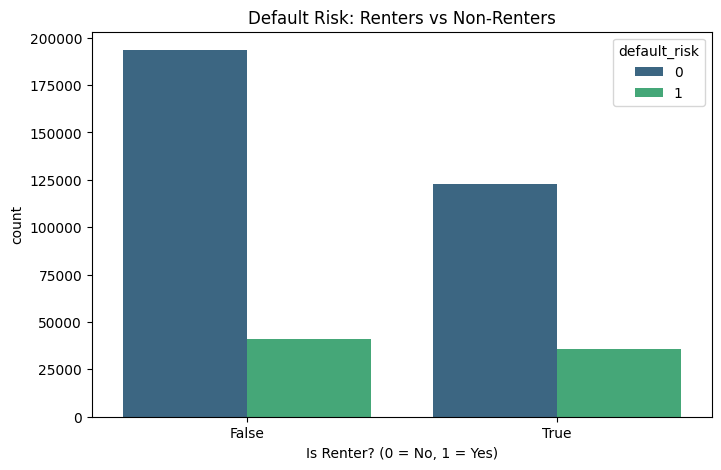

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='home_ownership_RENT', hue='default_risk', palette='viridis')
plt.title('Default Risk: Renters vs Non-Renters')
plt.xlabel('Is Renter? (0 = No, 1 = Yes)')
plt.show()